In [72]:
import pandas as pd
import numpy as np
import scipy.stats as sp
import matplotlib as mp
import matplotlib.pyplot as plt
%matplotlib inline

#Get the dataframe

data = pd.read_csv('dubaiCars.csv')

#Descriptve Statistics

'''
The mean tells the average of each column, the max and min tell the respective max and min in each column,
and the standard deviation tells where most of the data resides. For example the standard deviation of the cars' price is above the mean, meaning most cars within the data set
are more expensive than the average price of all the cars.
'''

data.fillna(0,inplace=True)

#Getting rid of European words #USA BABY
data.loc[data['fuel_type'] == 'Petrol', 'fuel_type'] = 'Gasoline'
data['kilometers'] = data['kilometers'] /(1.609344)
data.rename(columns={"kilometers":"miles"},inplace=True)



combustion = data.query(" fuel_type == 'Gasoline' or fuel_type == 'Diesel'")
#Get data

combustionLowMiles = combustion.query("miles < 50000")
combustionHighMiles = combustion.query("miles >= 50000")
combustionYoung = combustion.query("vehicle_age_years < 5")
combustionOld = combustion.query("vehicle_age_years >= 5")
combustionGas = combustion.query("fuel_type == 'Gasoline' ")
combustionDiesel = combustion.query("fuel_type == 'Diesel' ")


data.describe()

,price,miles,vehicle_age_years,no_of_cylinders
count,9953.000000,9.953000e+03,9953.000000,9953.000000
mean,162009.236311,5.087360e+04,5.881845,5.751432
std,187120.064955,5.610433e+04,5.163806,2.195505
min,1000.000000,0.000000e+00,0.000000,0.000000
25%,44900.000000,1.176939e+04,2.000000,4.000000
50%,92000.000000,4.225324e+04,5.000000,6.000000
75%,205000.000000,7.611797e+04,8.000000,8.000000
max,999900.000000,1.603138e+06,68.000000,12.000000


In [73]:
print(data['price'].mode())
print(data['miles'].mode())
print(data['vehicle_age_years'].mode())
print(data['no_of_cylinders'].mode())
print(data['fuel_type'].mode())


0    55000
Name: price, dtype: int64
0    0.0
Name: miles, dtype: float64
0    1
Name: vehicle_age_years, dtype: int64
0    4
Name: no_of_cylinders, dtype: int64
0    Gasoline
Name: fuel_type, dtype: object


In [74]:
'''
#Correlation
H0: Of the combustion cars the, one's with higher cylinder counts have no change in price
HA: Of the combustion cars the, one's with higher cylinder counts are higher in price

#Variability
H0: No significant variablity/variability happens by chance
HA: Significant difference in variance

#ANOVA
H0: Of the combustion cars, mileage, car age, and fuel type has no effect on pricing
HA: Of the combustion cars, mileage, car age, and fuel type has an effect on pricing.
'''


correlation = sp.pearsonr(combustion['price'],combustion['no_of_cylinders'])
print("Correlation between Price and Cylinder Count")
print("Correlation Coefficient:\t", correlation[0])
print("P-Value:\t\t\t",correlation[1])

levene = sp.levene(
    combustionOld['price'],
    combustionYoung['price'],
    combustionDiesel['price'],
    combustionGas['price'],
    combustionHighMiles['price'],
    combustionLowMiles['price']
)

print("\n\nVariability")
print("===========")
print(f"P-Value: {levene.pvalue:.6}\n\n")

anova = sp.f_oneway(
    combustionOld['price'],
    combustionYoung['price'],
    combustionDiesel['price'],
    combustionGas['price'],
    combustionHighMiles['price'],
    combustionLowMiles['price']
)

#Getting price averages
combustionYoung = round(combustionYoung['price'].sum() / combustionYoung['price'].count(),2)
combustionOld = round(combustionOld['price'].sum() / combustionOld['price'].count(),2)
combustionDiesel = round(combustionDiesel['price'].sum() / combustionDiesel['price'].count(),2)
combustionGas = round(combustionGas['price'].sum() / combustionGas['price'].count(),2)
combustionHighMiles = round(combustionHighMiles['price'].sum() / combustionHighMiles['price'].count(),2)
combustionLowMiles = round(combustionLowMiles['price'].sum() / combustionLowMiles['price'].count(),2)

barVals = {'Type' : ['Old','Young','Diesel','Gas','HighMileage','LowMileage'], 'Price': [combustionOld,combustionYoung,combustionDiesel,combustionGas,combustionHighMiles,combustionLowMiles]}
bar = pd.DataFrame(data=barVals)


'''
Based on the correlation coefficient from the t-test between price and cylinder count
we can see that there is a moderate positive correlation to support the idea that as cylinder count increases so does the price.

Of the correlation, based on the p-value being less than the alpha of 0.05 we can reject the null hyopthesis and assume cylinder count does affect car prices.

Of the variability test, based on the p-value being less than the alpha of 0.05 we can accept the null and assume the variance in the data is by chance.

Of the ANOVA test, based on the p-value being less than the alpha of 0.05 we can reject the null hypothesis and assume that there is significant
variance between the prices of the cars based on mileage, car age, and fuel type.
'''

print("\nAnova")
print("============")
print(f"P-Value: {anova.pvalue:.6}")

Correlation between Price and Cylinder Count
Correlation Coefficient:	 0.34338022237796173
P-Value:			 2.3135567139581487e-265


Variability
P-Value: 0.0



Anova
P-Value: 0.0


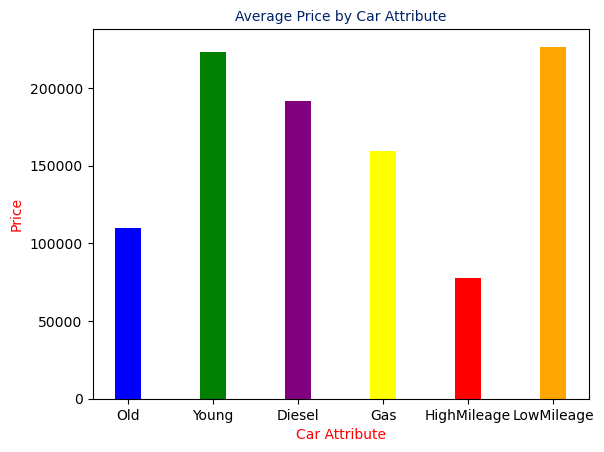

In [75]:
bar2 = plt.bar(bar["Type"], bar["Price"], color = ['blue','green','purple','yellow','red','orange'],width=0.3)
plt.xlabel("Car Attribute",color='red', fontsize=10)
plt.ylabel("Price",color='red', fontsize=10)
plt.title('Average Price by Car Attribute', color = "#002266", fontsize =10)
plt.show()